In [ ]:
%reset -f

In [ ]:
import pandas as pd
LATITUDE = 42.32144345767859
LONGITUDE = -83.2322888837106

TIMEZONE = "America/Detroit"

START_DATE = pd.to_datetime("2025-09-16 00:00:00").tz_localize(TIMEZONE)
END_DATE = pd.to_datetime("2026-07-16 23:00:00").tz_localize(TIMEZONE)

NOAA_MODEL = "ncep_gfs_seamless"

TILT=30
AZIMUTH=0

In [ ]:
data_raw = pd.read_excel("ELB Solar Hourly.xlsx")
data_raw['Date/Time'] = pd.to_datetime(data_raw['Date/Time']).dt.tz_localize(TIMEZONE, ambiguous='infer')
data = data_raw.copy()

In [ ]:
%%script true
import requests

url = (
    f"https://historical-forecast-api.open-meteo.com/v1/forecast?"
    f"latitude={LATITUDE}&longitude={LONGITUDE}&"
    f"start_hour={START_DATE.tz_convert('UTC').strftime("%Y-%m-%dT%H:%M")}&end_hour={END_DATE.tz_convert('UTC').strftime("%Y-%m-%dT%H:%M")}&"
    f"hourly=temperature_2m,cloud_cover,direct_radiation,diffuse_radiation,global_tilted_irradiance,weather_code,sunshine_duration,relative_humidity_2m,dewpoint_2m,wind_speed_10m,snow_depth,cloud_cover_low,cloud_cover_mid,cloud_cover_high&"
    f"models={NOAA_MODEL}&"
    f"tilt={TILT}&azimuth={AZIMUTH}&"
    f"timezone={TIMEZONE}"
)

response = requests.get(url).json()
weather_df = pd.DataFrame(response["hourly"])

weather_df["date"] = pd.to_datetime(weather_df["time"])
weather_df = weather_df.drop(columns=["time"])
weather_df['date'] = weather_df['date'].dt.tz_localize('UTC')

weather_df.to_csv("ELB_weather.csv", index=False)

In [ ]:
weather_data_raw = pd.read_csv("ELB_weather.csv")
weather_data = weather_data_raw.copy()
weather_data['date'] = pd.to_datetime(weather_data_raw['date']).dt.tz_convert(TIMEZONE)

In [ ]:
weather_data['weather_code'] = weather_data['weather_code'].astype('category')

In [ ]:
!pip install pvlib
import pvlib

times = pd.date_range(START_DATE, END_DATE, freq="h", tz=TIMEZONE)
times = times.tz_convert("UTC")
solpos = pvlib.solarposition.get_solarposition(times, LATITUDE, LONGITUDE)

aoi = pvlib.irradiance.aoi(
    surface_tilt=30,
    surface_azimuth=180,
    solar_zenith=solpos['zenith'],
    solar_azimuth=solpos['azimuth']
)

iam = pvlib.iam.physical(aoi)

cell_temp = pvlib.temperature.faiman(
    poa_global=weather_data['global_tilted_irradiance'],
    temp_air=weather_data['temperature_2m'],
    wind_speed=weather_data['wind_speed_10m']
)

pvlib_data = pd.DataFrame ({
    'date': times.values,
    'elevation': solpos.elevation.values,
    'aoi': aoi.values,
    'iam': iam.values,
    'cell_temp': cell_temp.values
})

pvlib_data['date'] = pvlib_data['date'].dt.tz_localize('UTC', ambiguous='infer').dt.tz_convert(TIMEZONE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 116.6 MB/s eta 0:00:00


In [ ]:
data = data.drop(columns=['Date', 'Hour (0-23)', 'Meter Production (kWh)'])
data = data.rename(columns={
    'Site Performance  (kWh)': 'kwh',
    'Date/Time': 'date'
    })
data = data.merge(weather_data, on='date')
data = data.merge(pvlib_data, on='date')
data = data.set_index('date')
data_merged = data.copy()
data

,kwh,temperature_2m,cloud_cover,direct_radiation,diffuse_radiation,global_tilted_irradiance,weather_code,sunshine_duration,relative_humidity_2m,dewpoint_2m,wind_speed_10m,snow_depth,cloud_cover_low,cloud_cover_mid,cloud_cover_high,elevation,aoi,iam,cell_temp
date,,,,,,,,,,,,,,,,,,,
2025-09-16 00:00:00-04:00,0.000,14.9,2,0.0,0.0,0.0,0,0.00,82,11.9,4.3,0.0,2,0,0,-40.922910,153.598965,0.000000,14.900000
2025-09-16 01:00:00-04:00,0.000,14.1,0,0.0,0.0,0.0,0,0.00,85,11.6,3.2,0.0,0,0,0,-44.698142,163.611853,0.000000,14.100000
2025-09-16 02:00:00-04:00,0.000,13.8,0,0.0,0.0,0.0,0,0.00,84,11.1,6.3,0.0,0,0,0,-44.564449,163.134545,0.000000,13.800000
2025-09-16 03:00:00-04:00,0.000,13.1,4,0.0,0.0,0.0,0,0.00,90,11.5,2.6,0.0,4,0,0,-40.555642,152.712543,0.000000,13.100000
2025-09-16 04:00:00-04:00,0.000,13.4,8,12.0,21.0,31.9,0,2473.05,90,11.7,2.1,0.0,8,0,0,-33.526394,139.395107,0.000000,14.210385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-16 19:00:00-04:00,3.613,24.4,21,0.0,0.0,0.0,1,0.00,61,16.4,5.2,0.0,21,0,0,21.146845,76.597686,0.736654,24.400000
2026-07-16 20:00:00-04:00,0.635,23.7,0,0.0,0.0,0.0,0,0.00,58,15.0,3.1,0.0,0,0,0,10.423013,90.330549,0.000000,23.700000
2026-07-16 21:00:00-04:00,0.000,22.3,0,0.0,0.0,0.0,0,0.00,61,14.4,1.8,0.0,0,0,0,0.305641,103.750198,0.000000,22.300000


In [ ]:
data['kwh'] = data['kwh'].interpolate(method='linear')
data_filled = data.copy()

In [ ]:
import numpy as np

data['hour'] = data.index.hour
data['doy'] = data.index.dayofyear - 1

data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24.0)
data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24.0)

data["doy_sin"] = np.sin(2 * np.pi * (data["doy"]) / 365.0)
data["doy_cos"] = np.cos(2 * np.pi * (data["doy"]) / 365.0)

data = pd.get_dummies(data, columns=['weather_code'], prefix='wc')
weather_code_cols = [col for col in data.columns if col.startswith('wc_')]
data_postproc_xgboost = data.copy()

In [ ]:
!pip install darts[torch]
from darts import TimeSeries
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler

data.index = data.index.tz_convert('utc')

target_series = TimeSeries.from_dataframe(
    data, value_cols=["kwh"], freq="h"
)

covariates_series = TimeSeries.from_dataframe(
    data, value_cols = ['elevation'],
    fill_missing_dates=True, freq="1h"
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.3 MB/s eta 0:00:00


In [ ]:
target_train, target_val = target_series.split_after(0.8)

target_scaler = Scaler()
covariates_scaler = Scaler()

target_train = target_scaler.fit_transform(target_train)
target_val = target_scaler.transform(target_val)

covariates = covariates_scaler.fit_transform(covariates_series)

In [ ]:
model = XGBModel(
    lags=3,
    lags_future_covariates=(0, 4),
    output_chunk_length=3,
    n_estimators=274, random_state=69420, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511,
    tree_method = "hist",
    #multi_models=False,
    device = 'cuda',
    kwargs={
        "tree_method": "hist",
        "device": "cuda"
    }
)


model.fit(
    series=target_train,
    future_covariates=covariates,
    val_series=target_val,
    val_future_covariates=covariates,
)

[0]	validation_0-rmse:0.43988
[1]	validation_0-rmse:0.43321
[2]	validation_0-rmse:0.42679
[3]	validation_0-rmse:0.42033
[4]	validation_0-rmse:0.41395
[5]	validation_0-rmse:0.40766
[6]	validation_0-rmse:0.40147
[7]	validation_0-rmse:0.39540
[8]	validation_0-rmse:0.38941
[9]	validation_0-rmse:0.38359
[10]	validation_0-rmse:0.37786
[11]	validation_0-rmse:0.37213
[12]	validation_0-rmse:0.36660
[13]	validation_0-rmse:0.36112
[14]	validation_0-rmse:0.35582
[15]	validation_0-rmse:0.35046
[16]	validation_0-rmse:0.34521
[17]	validation_0-rmse:0.34010
[18]	validation_0-rmse:0.33512
[19]	validation_0-rmse:0.33011
[20]	validation_0-rmse:0.32515
[21]	validation_0-rmse:0.32029
[22]	validation_0-rmse:0.31549
[23]	validation_0-rmse:0.31078
[24]	validation_0-rmse:0.30614
[25]	validation_0-rmse:0.30153
[26]	validation_0-rmse:0.29709
[27]	validation_0-rmse:0.29268
[28]	validation_0-rmse:0.28853
[29]	validation_0-rmse:0.28429
[30]	validation_0-rmse:0.28011
[31]	validation_0-rmse:0.27600
[32]	validation_0-

XGBModel(lags=3, lags_past_covariates=None, lags_future_covariates=(0, 4), output_chunk_length=3, output_chunk_shift=0, add_encoders=None, likelihood=None, quantiles=None, random_state=69420, multi_models=True, use_static_covariates=True, n_estimators=274, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511, tree_method=hist, device=cuda, kwargs={'tree_method': 'hist', 'device': 'cuda'})

In [ ]:
import numpy as np
import pandas as pd
from darts import metrics

full_target = target_train.concatenate(target_val)

# 1. Generate 24-hour historical forecasts (returns a list of 24h TimeSeries)
historical_forecasts = model.historical_forecasts(
    series=full_target,
    future_covariates=covariates,
    start=target_val.start_time(),
    forecast_horizon=24,
    stride=1,
    last_points_only=False,
    retrain=False,
    verbose=True,
)

# 2. Inverse transform each forecast slice individually
historical_forecasts = [
    target_scaler.inverse_transform(ts) for ts in historical_forecasts
]

# 3. Post-process: Clip negative predictions (solar output cannot be < 0)
historical_forecasts = [
    ts.map(lambda x: np.maximum(0, x)) for ts in historical_forecasts
]

# 4. Align actual validation targets for each forecast slice
actual_slices = [
    target_scaler.inverse_transform(full_target[ts.start_time() : ts.end_time()])
    for ts in historical_forecasts
]

# --- Overall Metrics Across All Slices ---
rmse = metrics.rmse(actual_slices, historical_forecasts, series_reduction=np.mean)
mae = metrics.mae(actual_slices, historical_forecasts, series_reduction=np.mean)
r2 = metrics.r2_score(actual_slices, historical_forecasts, series_reduction=np.mean)

print(f"Overall 24h Rolling - RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")


historical forecasts:   0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [10:51:57] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
historical forecasts: 100%|██████████| 1/1 [00:00<00:00,  8.38it/s]


Overall 24h Rolling - RMSE: 0.5503 | MAE: 0.3855 | R2: 0.9975


In [ ]:
start_time = pd.Timestamp("2025-10-1 00:00:00").tz_localize(TIMEZONE).tz_convert('utc').tz_localize(None) # Objectively fried time tomfoolery
end_time = pd.Timestamp("2025-10-2 00:00:00").tz_localize(TIMEZONE).tz_convert('utc').tz_localize(None)

full_series = target_train.concatenate(target_val)

historical_context = full_series[:start_time]

# 6. Predict
forecast_scaled = model.predict(
    n=720,
    series=historical_context,
    future_covariates=covariates,
)

forecast = target_scaler.inverse_transform(forecast_scaled)

forecast = forecast.map(lambda x: np.maximum(0, x))

<Figure size 1200x600 with 0 Axes>

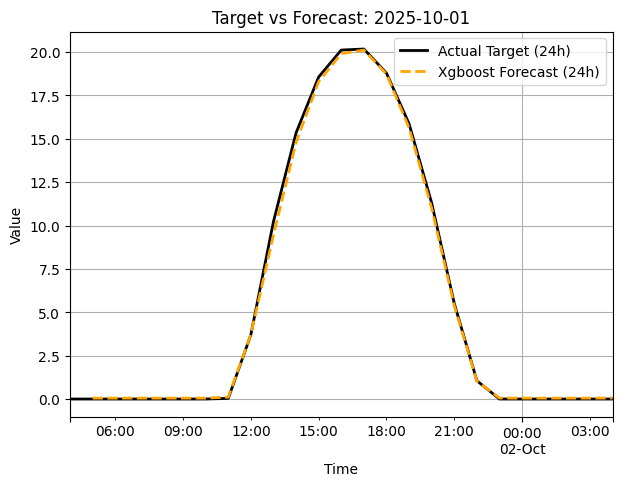

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

actual_24h = target_series.slice(start_time, end_time)
forecast_24h = forecast.slice(start_time, end_time)

plt.figure(figsize=(7, 5))
actual_24h.plot(label="Actual Target (24h)", color="black", linewidth=2)
forecast_24h.plot(
    label="Xgboost Forecast (24h)", color="orange", linestyle="--", linewidth=2
)

plt.title(f"Target vs Forecast: {start_time.date()}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from darts.dataprocessing.transformers import Diff

differencer = Diff()
target_stationary = differencer.fit_transform(full_target)
target_val_stationary = differencer.transform(target_val)

In [ ]:

from darts.explainability import ShapExplainer

target_time = pd.Timestamp("2025-09-20 00:00:00").tz_localize(TIMEZONE).tz_convert('utc').tz_localize(None)

#start_window = target_time - pd.Timedelta(days=1)
#end_window = target_time + pd.Timedelta(days=1)

#target_stationary = target_stationary[start_window : end_window]


shap_explainer = ShapExplainer(
    model=model,
    background_series=target_series,
    background_future_covariates=covariates,
)

shap_result = shap_explainer.explain(
    foreground_series=target_series,
    foreground_future_covariates=covariates,
)

/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:544: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return adfuller(ts.univariate_values(copy=False), maxlag, regression, autolag)
/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:492: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  return kpss(ts.univariate_values(copy=False), regression, nlags)
/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:492: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which

/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:544: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return adfuller(ts.univariate_values(copy=False), maxlag, regression, autolag)
/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:492: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  return kpss(ts.univariate_values(copy=False), regression, nlags)
/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:492: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which

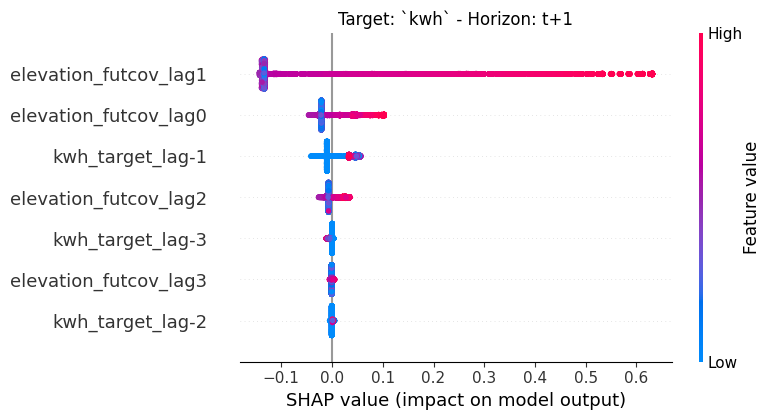

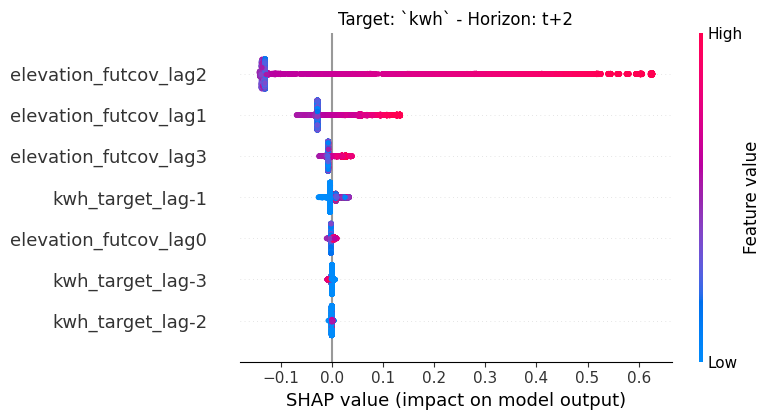

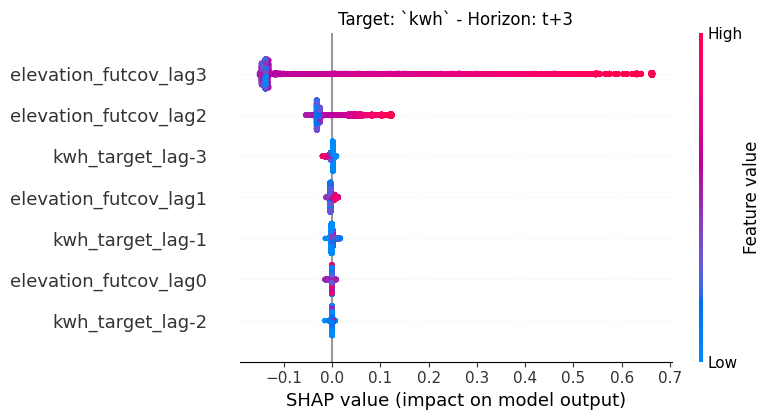

In [ ]:
shap_explainer.summary_plot()
plt.show()

In [ ]:
toi = covariates[:134]

exp_res = shap_explainer.explain_single(foreground_series=target_series, foreground_future_covariates=toi)

/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:544: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return adfuller(ts.univariate_values(copy=False), maxlag, regression, autolag)
/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:492: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  return kpss(ts.univariate_values(copy=False), regression, nlags)
/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:492: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which

In [ ]:
temp = exp_res.explained_components['kwh'][0].to_dataframe()
sorted_cols = temp.iloc[0].abs().sort_values(ascending=False).index
temp = temp[sorted_cols]
temp

,elevation_futcov_lag1,elevation_futcov_lag0,kwh_target_lag-1,elevation_futcov_lag2,elevation_futcov_lag3,kwh_target_lag-2,kwh_target_lag-3
2025-09-21 14:00:00,0.345691,0.042098,0.040204,0.02745,0.001129,0.0009,-0.000583


In [ ]:
%%script true
explainer.force_plot()
plt.show()

In [ ]:
data_tabular_cv = covariates.to_dataframe()

cols = covariates.columns.tolist()

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

for col in cols:
  for i in range(0,4):
    col_name = f"{col}_futcov_lag{i}"
    data_tabular_cv[col_name] = data_tabular_cv[col].shift(-i)
    #print(f"Column: {col_name}")

data_tabular_cv = data_tabular_cv.drop(columns=cols)

cols = target_val.columns.tolist()
data_tabular_t = full_target.to_dataframe()
for col in cols:
  for i in range(-1,-4,-1):
    col_name = f"{col}_target_lag{i}"
    #print(f"Column: {col_name}")
    data_tabular_t[col_name] = data_tabular_t[col].shift(-i)

data_tabular = data_tabular_cv.merge(data_tabular_t, left_index=True, right_index=True)

data_tabular = data_tabular.dropna()

data_tabular = data_tabular.drop(columns='kwh')

data_tabular = data_tabular.copy()


In [ ]:
!pip install lime

from lime.lime_tabular import LimeTabularExplainer


explainer = LimeTabularExplainer(
    training_data = data_tabular.values,
    feature_names=data_tabular.columns,
    mode="regression",
    random_state=42,
    discretize_continuous=False,
)

def predict_fn(data):
  print(data.shape)

  prediction = model.model.predict(data)

  prediction = prediction[:, 0]
  print(prediction.shape)
  return prediction


num_features = len(data_tabular.columns)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=dc8261df24df7a5c6d4b1ccb8d7de514c4a08d4b3db43051dc51ecdd05ed2ea1
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [ ]:
data_row = data_tabular.iloc[128]

print(data_row.name)

exp = explainer.explain_instance(
        data_row=data_row.to_numpy(),
        predict_fn=predict_fn,
        num_features=num_features,
)


2025-09-21 15:00:00
(5000, 7)
(5000,)


In [ ]:
toi = target_series[:128]
res = model.predict(3, toi, future_covariates=covariates)
local_shap = shap_explainer.explain_single(foreground_series=toi, foreground_future_covariates=toi)
local_shap.explained_components



/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:544: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return adfuller(ts.univariate_values(copy=False), maxlag, regression, autolag)
/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:492: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  return kpss(ts.univariate_values(copy=False), regression, nlags)
/usr/local/lib/python3.13/dist-packages/darts/utils/statistics.py:492: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which

{'kwh':                      kwh_target_lag-3  kwh_target_lag-2  kwh_target_lag-1  elevation_futcov_lag0  elevation_futcov_lag1  elevation_futcov_lag2  elevation_futcov_lag3
 2025-09-21 08:00:00          0.000201         -0.000577         -0.009880              -0.021100              -0.133745              -0.006976              -0.000776
 2025-09-21 09:00:00          0.000081         -0.000389         -0.003718              -0.001817              -0.028356              -0.131068              -0.007480
 2025-09-21 10:00:00          0.001414         -0.000057         -0.000967              -0.000338              -0.003503              -0.031731              -0.137944
 
 shape: (3, 7, 1), freq: h, size: 84.00 B}

In [ ]:
def build_solar_forecast_explanation_prompt(
    forecast: pd.DataFrame| dict[str, any],
    local_shap: pd.DataFrame | dict[str, any],
    global_shap: dict[int, dict[str, any]],
    model_inputs: pd.DataFrame | dict[str, any],
    horizon_length: int = 3,
    target_col: str = "kwh"
) -> str:
    if isinstance(local_shap, dict) and target_col in local_shap:
        df_local = local_shap[target_col]
    else:
        df_local = local_shap
    df_local_horizon = df_local.to_dataframe().head(horizon_length)

    if isinstance(forecast, dict):
        df_forecast = list(forecast.values())[0] if forecast else pd.DataFrame()
    else:
        df_forecast = forecast
    df_forecast_horizon = df_forecast.to_dataframe().head(horizon_length)

    global_importance_summary = {}
    for step in range(1, horizon_length + 1):
        if step in global_shap:
            step_data = global_shap[step]
            df_global_step = step_data[target_col] if isinstance(step_data, dict) else step_data

            mean_abs_shap = df_global_step.to_dataframe().abs().mean().sort_values(ascending=False)
            global_importance_summary[f"Step {step}"] = mean_abs_shap.round(6).to_dict()

    local_shap_str = df_local_horizon.round(6).to_string()
    forecast_str = df_forecast_horizon.round(6).to_string()
    global_shap_lines = []
    for step_name, feature_map in global_importance_summary.items():
        global_shap_lines.append(f"--- {step_name} Global Feature Importance (Mean |SHAP|) ---")
        for feat, score in feature_map.items():
            global_shap_lines.append(f"  - {feat}: {score:.6f}")
    global_shap_str = "\n".join(global_shap_lines)

    df_inputs = model_inputs['kwh'].to_dataframe()
    inputs_str = df_inputs.to_string()


    prompt = f"""You are an expert energy data scientist explaining a solar power generation forecast to an inexperienced operator. Use language and context understanable for the average layperson.
### TASK:
Explain the predicted solar energy output for the next {horizon_length} time step(s). Highlight key drivers (local feature contributions) and contrast them with historical feature importance (global model behavior).

---

### 1. FORECAST VALUES ({horizon_length}-Step Horizon):
{forecast_str}

---

### 2. LOCAL SHAP VALUES (Feature contributions for this specific prediction):
*Positive values pushed the forecast higher; negative values pulled it lower.*
{local_shap_str}

---

### 3. GLOBAL SHAP METRICS (Historical Mean Absolute SHAP across steps):
*Reflects overall feature reliance across all historical training/validation data.*
{global_shap_str}

---

### 4. MODEL INPUT FEATURES (Actual feature values used for this forecast):
{inputs_str}

### INSTRUCTIONS FOR YOUR EXPLANATION:
1. **Summary:** Give a brief high-level overview of the expected generation profile across the next {horizon_length} hour(s).
2. **Key Local Drivers:** Identify which specific features (e.g., target lags, solar elevation lags) contributed most positively or negatively at each horizon step.
3. **Global Context:** Compare local feature impact with global feature reliance—note if any feature played an unusually large or small role relative to historical averages.
4. **Actionable Takeaway:** Highlight any potential risks or anomalies an operational team should watch for. Keep explanations concise, professional, and clear.
"""
    return prompt

In [ ]:
prompt = build_solar_forecast_explanation_prompt(res, local_shap.explained_components, shap_result.explained_forecasts, local_shap.feature_values)

In [ ]:
print(prompt)

You are an expert energy data scientist explaining a solar power generation forecast to an inexperienced operator. Use language and context understanable for the average layperson.
### TASK:
Explain the predicted solar energy output for the next 3 time step(s). Highlight key drivers (local feature contributions) and contrast them with historical feature importance (global model behavior).

---

### 1. FORECAST VALUES (3-Step Horizon):
                          kwh
date                         
2025-09-21 12:00:00  0.224028
2025-09-21 13:00:00  0.431765
2025-09-21 14:00:00  0.601090

---

### 2. LOCAL SHAP VALUES (Feature contributions for this specific prediction):
*Positive values pushed the forecast higher; negative values pulled it lower.*
                     kwh_target_lag-3  kwh_target_lag-2  kwh_target_lag-1  elevation_futcov_lag0  elevation_futcov_lag1  elevation_futcov_lag2  elevation_futcov_lag3
2025-09-21 08:00:00          0.000201         -0.000577         -0.009880        